# Import libs and mount drive
For all module file and training pipeline file, please visit: https://github.com/quocbao8925/YOLO26-scratch

In [1]:
from google.colab import files, drive
import os

In [2]:
drive.mount('/content/drive')

# Copy your 3 training files to Colab

import shutil, os
src = '/content/drive/MyDrive/MIMIC26/ultralytics/main'  # adjust to your Drive path
for f in ['yolo26_modules.py', 'yolo26_loss.py', 'train26.py', 'predict26.py']:
    shutil.copy(os.path.join(src, f), f'/content/{f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import dataset

In [3]:
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    !mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
!kaggle datasets download -d quocbao8925/coco-person-only-320
!unzip -q coco-person-only-320.zip -d ./data

Dataset URL: https://www.kaggle.com/datasets/quocbao8925/coco-person-only-320
License(s): CC0-1.0
100% 2.30G/2.30G [00:25<00:00, 95.3MB/s]



# Fresh Training

In [ ]:
!python train26.py \
    --data /content/data/coco_person_320 \
    --nc 1 \
    --scale n \
    --epochs 100 \
    --batch 16 \
    --imgsz 640 \
    --save_dir /content/drive/MyDrive/MIMIC26/runs/yolo26

Using device: cuda
Train: 49811 images, Val: 2074 images

Starting training from epoch 1 to 100...

/content/train26.py:509: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/100: 100% 3113/3113 [16:53<00:00,  3.07it/s, Mem=2.5G, box=3.4865, cls=7.9181, dfl=0.0707]
  Epoch 1 complete — mAP50=0.5002  val_box=2.2691  val_cls=3.1504  val_dfl=0.0424  lr=0.003332
  Saved checkpoints to runs/yolo26/weights
Epoch 2/100: 100% 3113/3113 [17:07<00:00,  3.03it/s, Mem=2.5G, box=2.0140, cls=2.7294, dfl=0.0355]
  Epoch 2 complete — mAP50=0.4880  val_box=1.8083  val_cls=2.2935  val_dfl=0.0305  lr=0.006664
  Saved checkpoints to runs/yolo26/

# Resume Training After a Crash

In [ ]:
!ls /content/drive/MyDrive/MIMIC26/

In [ ]:
!python /content/train26.py \
    --data /content/data/coco_person_320 \
    --nc 1 \
    --scale n \
    --epochs 100 \
    --batch 16 \
    --imgsz 320 \
    --save_dir /content/drive/MyDrive/MIMIC26/runs/yolo26 \
    --resume auto

Using device: cuda
Train: 49811 images, Val: 2074 images
Resuming from /content/drive/MyDrive/MIMIC26/runs/yolo26/weights/last.pt
Resumed at epoch 2, best_fitness=0.5002

Starting training from epoch 3 to 100...

Epoch 3/100:  43% 1350/3113 [07:24<08:54,  3.30it/s, Mem=2.5G, box=1.8802, cls=2.3828, dfl=0.0319]

# Plot graph

In [4]:
from train26 import plot_results
plot_results('/content/drive/MyDrive/MIMIC26/runs/yolo26/results.csv',
             '/content/drive/MyDrive/MIMIC26/runs/yolo26')

Results plot saved to /content/drive/MyDrive/MIMIC26/runs/yolo26/results.png


# Test model


Image : /content/data/coco_person_320/images/val/000000419974.jpg
Label : /content/data/coco_person_320/labels/val/000000419974.txt  (exists=True)
Loading model...
Model cfg — nc=1, scale=n, reg_max=1
Model loaded OK
Image size: 320x320
Running inference...
Raw detections: 300,  max conf: 0.8845
After conf≥0.15 filter: 2 detections
GT boxes: 2


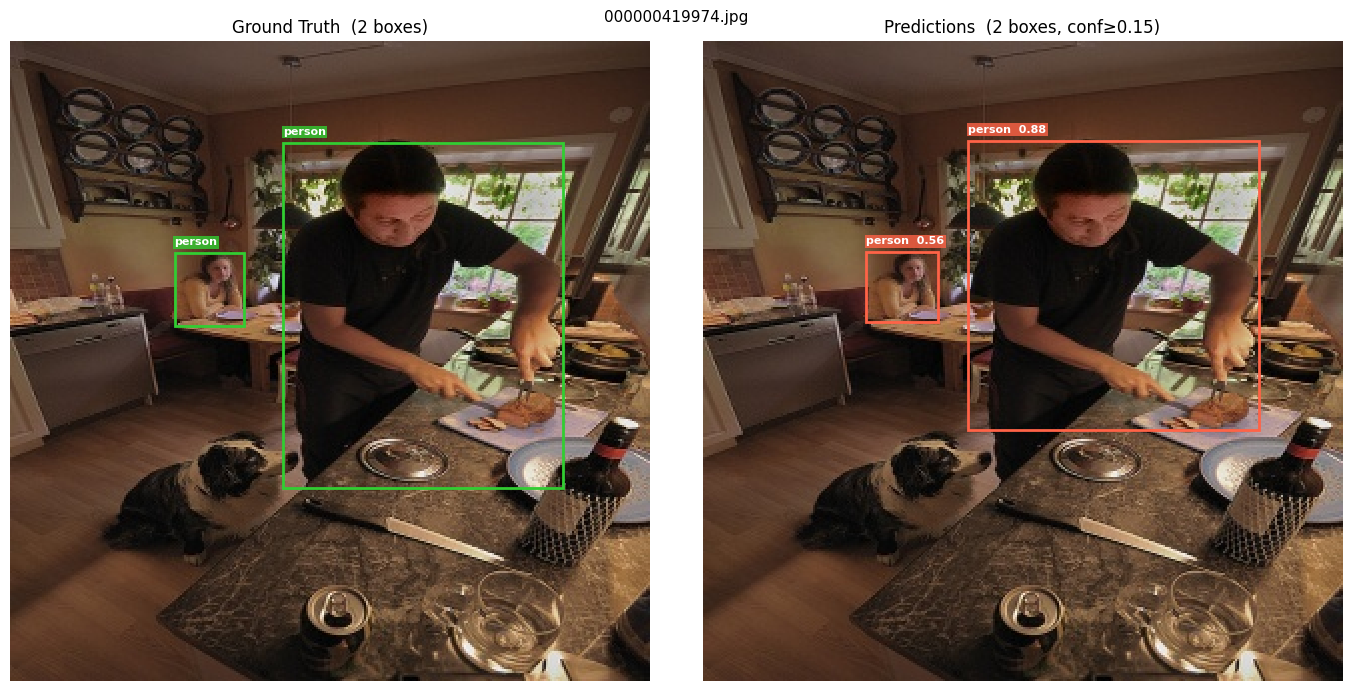

Done.


In [7]:
%matplotlib inline
import random, traceback
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from yolo26_modules import build_yolo26

try:
    # ── Config ───────────────────────────────────────────────────────────────
    WEIGHTS     = "/content/drive/MyDrive/MIMIC26/runs/yolo26/weights/last.pt"
    VAL_IMGS    = "/content/data/coco_person_320/images/val"
    VAL_LBLS    = "/content/data/coco_person_320/labels/val"
    NC          = 1
    CONF        = 0.25
    IMGSZ       = 320
    CLASS_NAMES = ["person"]

    # ── Letterbox (inlined — no predict26 import needed) ─────────────────────
    def letterbox(im, new_shape=640, color=(114, 114, 114)):
        shape = im.shape[:2]
        r = min(new_shape / shape[0], new_shape / shape[1])
        new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
        dw = (new_shape - new_unpad[0]) / 2
        dh = (new_shape - new_unpad[1]) / 2
        if shape[::-1] != new_unpad:
            im = cv2.resize(im, new_unpad, interpolation=cv2.INTER_LINEAR)
        top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
        left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
        im = cv2.copyMakeBorder(im, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
        return im, r, (dw, dh)

    # ── Pick random image ─────────────────────────────────────────────────────
    img_files = sorted(Path(VAL_IMGS).glob("*.jpg")) + sorted(Path(VAL_IMGS).glob("*.png"))
    assert img_files, f"No images found in {VAL_IMGS}"
    img_path = random.choice(img_files)
    lbl_path = Path(VAL_LBLS) / (img_path.stem + ".txt")
    print(f"Image : {img_path}")
    print(f"Label : {lbl_path}  (exists={lbl_path.exists()})")

    # ── Load model ────────────────────────────────────────────────────────────
    print("Loading model...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt   = torch.load(WEIGHTS, map_location=device, weights_only=False)
    cfg    = ckpt.get("model_cfg", {})

    # Fallback: infer nc directly from weight shapes if model_cfg missing
    sd  = ckpt["model_state_dict"]
    nc_from_weights = sd["detect.cv3.0.2.weight"].shape[0]
    nc      = cfg.get("nc",      nc_from_weights)
    scale   = cfg.get("scale",   "n")
    reg_max = cfg.get("reg_max", 1)
    print(f"Model cfg — nc={nc}, scale={scale}, reg_max={reg_max}")

    model = build_yolo26(nc=nc, scale=scale, reg_max=reg_max)
    model.load_state_dict(sd)
    model.to(device).eval()
    print("Model loaded OK")

    # ── Preprocess ────────────────────────────────────────────────────────────
    img0 = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    assert img0 is not None, f"cv2 could not read {img_path}"
    H0, W0 = img0.shape[:2]
    print(f"Image size: {W0}x{H0}")

    img_lb, ratio, (dw, dh) = letterbox(img0, IMGSZ)
    inp = torch.from_numpy(
        np.ascontiguousarray(img_lb.transpose(2, 0, 1).astype(np.float32) / 255.0)
    ).unsqueeze(0).to(device)

    # ── Inference ─────────────────────────────────────────────────────────────
    print("Running inference...")
    with torch.no_grad():
        y, _ = model(inp)

    pred = y[0]
    print(f"Raw detections: {len(pred)},  max conf: {pred[:, 4].max().item():.4f}")
    pred = pred[pred[:, 4] > CONF].clone()

    if len(pred):
        pred[:, [0, 2]] -= dw
        pred[:, [1, 3]] -= dh
        pred[:, :4]     /= ratio
        pred[:, [0, 2]]  = pred[:, [0, 2]].clamp(0, W0)
        pred[:, [1, 3]]  = pred[:, [1, 3]].clamp(0, H0)
    pred = pred.cpu().numpy()
    print(f"After conf≥{CONF} filter: {len(pred)} detections")

    # ── Parse GT labels ───────────────────────────────────────────────────────
    gt_boxes = []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = (cx - bw / 2) * W0;  y1 = (cy - bh / 2) * H0
            x2 = (cx + bw / 2) * W0;  y2 = (cy + bh / 2) * H0
            gt_boxes.append((cls_id, x1, y1, x2, y2))
    print(f"GT boxes: {len(gt_boxes)}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    def draw_boxes_on_ax(ax, image, boxes, color, label_fn):
        ax.imshow(image)
        ax.axis("off")
        for box in boxes:
            x1, y1, x2, y2 = [float(v) for v in box[:4]]
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor="none"
            ))
            ax.text(x1, max(y1 - 4, 0), label_fn(box),
                    color="white", fontsize=8, fontweight="bold",
                    bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(img_path.name, fontsize=11)

    axes[0].set_title(f"Ground Truth  ({len(gt_boxes)} boxes)")
    draw_boxes_on_ax(
        axes[0], img0,
        [[x1, y1, x2, y2] for _, x1, y1, x2, y2 in gt_boxes],
        color="limegreen",
        label_fn=lambda b: CLASS_NAMES[0]
    )

    axes[1].set_title(f"Predictions  ({len(pred)} boxes, conf≥{CONF})")
    draw_boxes_on_ax(
        axes[1], img0, pred,
        color="tomato",
        label_fn=lambda b: f"{CLASS_NAMES[int(b[5])]}  {b[4]:.2f}"
    )

    plt.tight_layout()
    plt.show()
    print("Done.")

except Exception:
    traceback.print_exc()